In [1]:
import numpy as np
import pandas as pd
import plotly.io as pio
from plotly import express as px

from src.data_preparation.evaluation import mean_ndcg_at_k
from src.modelling.models.linear_baseline import ContentBasedRanker
from src.modelling.models.ranker import (
    train_model,
    tune_hyperparameters,
)
from src.modelling.utils.data import (
    create_lgb_dataset,
    extract_features,
    load_parquet_files,
    split_for_tuning,
)
from src.modelling.utils.fairness import apply_calibration

pio.renderers.default = "png"

In [2]:
# --- 1. LOADING THE DATA ---
X_TRAIN_PATH = "../../outputs/features/X_train.parquet"
Y_TRAIN_PATH = "../../outputs/features/y_train.parquet"
X_VALID_PATH = "../../outputs/features/X_valid.parquet"
Y_VALID_PATH = "../../outputs/features/y_valid.parquet"
TRAIN_GROUP_PATH = "../../outputs/features/groups_train.parquet"
VALID_GROUP_PATH = "../../outputs/features/groups_valid.parquet"
X_TEST_PATH = "../../outputs/features/X_test.parquet"

X_FULL_PATH = "../../outputs/features/full_train_features.parquet"
Y_FULL_PATH = "../../outputs/features/y_full_train.parquet"
GROUPS_FULL_PATH = "../../outputs/features/groups_full_train.parquet"

In [3]:
x_train, y_train, groups_train = load_parquet_files(
    X_TRAIN_PATH, Y_TRAIN_PATH, TRAIN_GROUP_PATH
)
x_valid, y_valid, groups_valid = load_parquet_files(
    X_VALID_PATH, Y_VALID_PATH, VALID_GROUP_PATH
)

feature_cols = extract_features(x_valid)

In [4]:
# --- 1. Linear Baseline ---
baseline_model = ContentBasedRanker(alpha=10.0)
baseline_model.fit(x_train, y_train["relevance"])

valid_scores = baseline_model.predict(x_valid)

# Convert scores into an ordered recommendation list grouped by search query
final_valid_ranks = baseline_model.generate_ranking(y_valid, valid_scores)
print(
    "Linear baseline NDCG@5:", mean_ndcg_at_k(final_valid_ranks, prediction_col="score")
)

Linear baseline NDCG@5: 0.2800966342595715


In [5]:
# --- 2. 1.5 Calculating the sample weights based on the random_bool ---
def compute_data_driven_weights(x_df, y_df):
    """
    Computes sample weights based on the empirical signal strength
    of organic vs randomized search interactions.
    """
    if "random_bool" not in x_df.columns:
        return None

    print("📊 Calculating empirical signal-to-noise weights...")

    mean_relevance_organic = y_df.loc[x_df["random_bool"] == 0, "relevance"].mean()
    mean_relevance_random = y_df.loc[x_df["random_bool"] == 1, "relevance"].mean()

    signal_ratio = mean_relevance_random / mean_relevance_organic

    print(f"   ▫️ Organic Base Signal Level: {mean_relevance_organic:.4f}")
    print(f"   ▫️ Random Base Signal Level:  {mean_relevance_random:.4f}")
    print(f"   👉 Calculated Random Weight Penalty: {signal_ratio:.4f}")


# Execute the weighting function on your training split structures
train_sample_weights = compute_data_driven_weights(x_train, y_train)

📊 Calculating empirical signal-to-noise weights...
   ▫️ Organic Base Signal Level: 0.1935
   ▫️ Random Base Signal Level:  0.0682
   👉 Calculated Random Weight Penalty: 0.3522


In [6]:
# --- 2. Lambda Rank (default) ---
lgb_tune_train = create_lgb_dataset(
    x_train, y_train, groups_df=groups_train, feature_cols=feature_cols
)
lgb_tune_val = create_lgb_dataset(
    x_valid,
    y_valid,
    groups_df=groups_valid,
    reference=lgb_tune_train,
    feature_cols=feature_cols,
)

params = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "ndcg_eval_at": [5],
    "boosting_type": "gbdt",
    "max_depth": -1,
    "n_jobs": -1,
    "verbose": 1,
}

model = train_model(params=params, train_data=lgb_tune_train, valid_data=lgb_tune_val)

[LightGBM] [Info] Calculating query weights...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.236667 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17195
[LightGBM] [Info] Number of data points in the train set: 3966887, number of used features: 143
[LightGBM] [Info] Calculating query weights...
Training until validation scores don't improve for 50 rounds
[10]	valid_0's ndcg@5: 0.318011
[20]	valid_0's ndcg@5: 0.328075
[30]	valid_0's ndcg@5: 0.339465
[40]	valid_0's ndcg@5: 0.347793
[50]	valid_0's ndcg@5: 0.351592
[60]	valid_0's ndcg@5: 0.354398
[70]	valid_0's ndcg@5: 0.356467
[80]	valid_0's ndcg@5: 0.357757
[90]	valid_0's ndcg@5: 0.358301
[100]	valid_0's ndcg@5: 0.359688
[110]	valid_0's ndcg@5: 0.360282
[120]	valid_0's ndcg@5: 0.361456
[130]	valid_0's ndcg@5: 0.361581
[140]	valid_0's ndcg@5: 0.361688
[150]	valid_0's ndcg@5: 0.362349
[1

In [7]:
# --- 3. Lambda Rank (most important features only) ---
raw_gains = model.feature_importance(importance_type="gain")
importance_df = pd.DataFrame(
    {"feature": feature_cols, "gain_importance": raw_gains}
).sort_values(by="gain_importance", ascending=False)


# Compute fractional contributions and sequential running totals
importance_df["gain_fraction"] = (
    importance_df["gain_importance"] / importance_df["gain_importance"].sum()
)
importance_df["cumulative_gain"] = importance_df["gain_fraction"].cumsum()

THRESHOLD = 0.995
selected_features = importance_df[importance_df["cumulative_gain"] <= THRESHOLD][
    "feature"
].tolist()

print(f"Dropped {len(feature_cols) - len(selected_features)} columns!")

Dropped 72 columns!


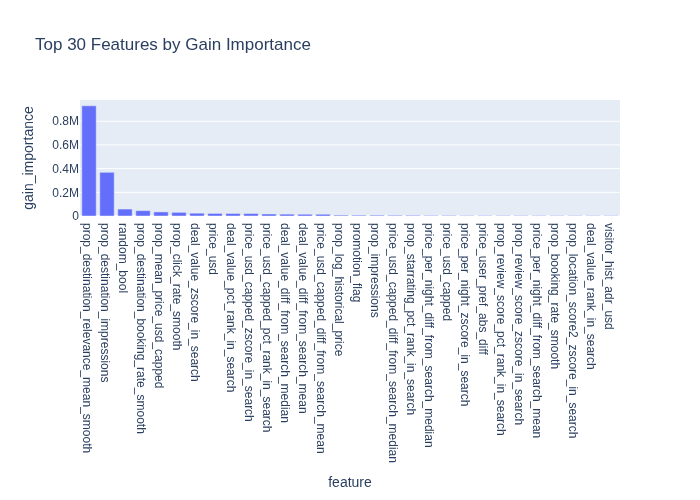

In [8]:
px.bar(
    importance_df.head(30),
    x="feature",
    y="gain_importance",
    title="Top 30 Features by Gain Importance",
)

In [12]:
# --- 2. Lambda Rank (default) ---
lgb_tune_train = create_lgb_dataset(
    x_train, y_train, groups_df=groups_train, feature_cols=selected_features
)
lgb_tune_val = create_lgb_dataset(
    x_valid,
    y_valid,
    groups_df=groups_valid,
    reference=lgb_tune_train,
    feature_cols=selected_features,
)

params = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "ndcg_eval_at": [5],
    "boosting_type": "gbdt",
    "max_depth": -1,
    "n_jobs": -1,
    "verbose": 1,
}

model = train_model(params=params, train_data=lgb_tune_train, valid_data=lgb_tune_val)

[LightGBM] [Info] Calculating query weights...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.153776 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14596
[LightGBM] [Info] Number of data points in the train set: 3966887, number of used features: 71
[LightGBM] [Info] Calculating query weights...
Training until validation scores don't improve for 50 rounds
[10]	valid_0's ndcg@5: 0.318011
[20]	valid_0's ndcg@5: 0.328075
[30]	valid_0's ndcg@5: 0.338564
[40]	valid_0's ndcg@5: 0.345913
[50]	valid_0's ndcg@5: 0.350109
[60]	valid_0's ndcg@5: 0.353602
[70]	valid_0's ndcg@5: 0.355039
[80]	valid_0's ndcg@5: 0.355805
[90]	valid_0's ndcg@5: 0.35729
[100]	valid_0's ndcg@5: 0.35913
[110]	valid_0's ndcg@5: 0.359842
[120]	valid_0's ndcg@5: 0.360683
[130]	valid_0's ndcg@5: 0.361039
[140]	valid_0's ndcg@5: 0.361289
[150]	valid_0's ndcg@5: 0.361472
[160]

In [9]:
# --- 4. Hyperparam tuning ---
# Using all the features - since dropping them by importance gain doesn't pay off

groups = split_for_tuning(x_train, y_train, groups_train, split_ratio=0.1)

lgb_tune_train = create_lgb_dataset(
    groups["x_train"],
    groups["y_train"],
    groups_df=groups["groups_train"],
    feature_cols=feature_cols,
)
lgb_tune_val = create_lgb_dataset(
    groups["x_val"],
    groups["y_val"],
    groups_df=groups["groups_val"],
    reference=lgb_tune_train,
    feature_cols=feature_cols,
)

hyper_parmas = tune_hyperparameters(lgb_tune_train, lgb_tune_val, n_iter=16)

▶️ Iteration 1/16...
▶️ Iteration 2/16...
▶️ Iteration 3/16...
▶️ Iteration 4/16...
▶️ Iteration 5/16...
▶️ Iteration 6/16...
▶️ Iteration 7/16...
▶️ Iteration 8/16...
▶️ Iteration 9/16...
▶️ Iteration 10/16...
▶️ Iteration 11/16...
▶️ Iteration 12/16...
▶️ Iteration 13/16...
▶️ Iteration 14/16...
▶️ Iteration 15/16...
▶️ Iteration 16/16...
🏁 Tuning finished. Best NDCG@5: 0.59424


In [10]:
lgb_tune_train = create_lgb_dataset(
    x_train, y_train, groups_df=groups_train, feature_cols=feature_cols
)
lgb_tune_val = create_lgb_dataset(
    x_valid,
    y_valid,
    groups_df=groups_valid,
    reference=lgb_tune_train,
    feature_cols=feature_cols,
)

model = train_model(
    params=hyper_parmas, train_data=lgb_tune_train, valid_data=lgb_tune_val
)

Training until validation scores don't improve for 50 rounds
[10]	valid_0's ndcg@5: 0.318566
[20]	valid_0's ndcg@5: 0.319958
[30]	valid_0's ndcg@5: 0.32534
[40]	valid_0's ndcg@5: 0.329441
[50]	valid_0's ndcg@5: 0.336119
[60]	valid_0's ndcg@5: 0.338412
[70]	valid_0's ndcg@5: 0.344638
[80]	valid_0's ndcg@5: 0.347546
[90]	valid_0's ndcg@5: 0.349904
[100]	valid_0's ndcg@5: 0.350709
[110]	valid_0's ndcg@5: 0.352313
[120]	valid_0's ndcg@5: 0.354812
[130]	valid_0's ndcg@5: 0.355996
[140]	valid_0's ndcg@5: 0.356828
[150]	valid_0's ndcg@5: 0.357256
[160]	valid_0's ndcg@5: 0.358468
[170]	valid_0's ndcg@5: 0.35871
[180]	valid_0's ndcg@5: 0.359192
[190]	valid_0's ndcg@5: 0.35958
[200]	valid_0's ndcg@5: 0.360195
[210]	valid_0's ndcg@5: 0.360362
[220]	valid_0's ndcg@5: 0.360338
[230]	valid_0's ndcg@5: 0.360679
[240]	valid_0's ndcg@5: 0.36036
[250]	valid_0's ndcg@5: 0.360253
[260]	valid_0's ndcg@5: 0.360631
[270]	valid_0's ndcg@5: 0.361041
[280]	valid_0's ndcg@5: 0.361366
[290]	valid_0's ndcg@5: 0.36

In [12]:
y_pred = model.predict(x_valid[feature_cols])

In [13]:
# --- 5. Fairness Checks ---

# Are the "chain" hotels ranked higher on average than the "independent" hotels?
df_eval = x_valid[
    ["srch_id", "prop_brand_bool", "domestic_trip_indicator", "prop_review_score"]
].copy()
df_eval["booking_bool"] = y_valid["booking_bool"]
df_eval["score"] = y_pred

# 2. Compute within-search ranks based on your model's predicted utility scores
df_eval["predicted_rank"] = df_eval.groupby("srch_id")["score"].rank(
    ascending=False, method="first"
)

# 3. Isolate the records where an actual booking occurred
df_bookings = df_eval[df_eval["booking_bool"] == 1].copy()

print("📊 RUNNING RECONNAISSANCE FAIRNESS CHECKS...")
print("-" * 65)

# --- CHECK 1: Brand Bias (Chain vs. Independent) ---
mean_rank_chain = df_bookings[df_bookings["prop_brand_bool"] == 1][
    "predicted_rank"
].mean()
mean_rank_indep = df_bookings[df_bookings["prop_brand_bool"] == 0][
    "predicted_rank"
].mean()
print(f"🏨 Chain Hotels Avg Predicted Rank:       {mean_rank_chain:.2f}")
print(f"🏨 Independent Hotels Avg Predicted Rank: {mean_rank_indep:.2f}")
print(
    f"   👉 Disparity Delta:                   {abs(mean_rank_chain - mean_rank_indep):.2f} positions"
)

# --- CHECK 2: Geographic Context (Domestic vs International) ---
mean_rank_dom = df_bookings[df_bookings["domestic_trip_indicator"] == 1][
    "predicted_rank"
].mean()
mean_rank_intl = df_bookings[df_bookings["domestic_trip_indicator"] == 0][
    "predicted_rank"
].mean()
print(f"\n✈️  Domestic Stays Avg Predicted Rank:     {mean_rank_dom:.2f}")
print(f"✈️  International Stays Avg Predicted Rank:{mean_rank_intl:.2f}")
print(
    f"   👉 Disparity Delta:                   {abs(mean_rank_dom - mean_rank_intl):.2f} positions"
)
print("-" * 65)

📊 RUNNING RECONNAISSANCE FAIRNESS CHECKS...
-----------------------------------------------------------------
🏨 Chain Hotels Avg Predicted Rank:       7.57
🏨 Independent Hotels Avg Predicted Rank: 7.53
   👉 Disparity Delta:                   0.04 positions

✈️  Domestic Stays Avg Predicted Rank:     7.57
✈️  International Stays Avg Predicted Rank:7.54
   👉 Disparity Delta:                   0.03 positions
-----------------------------------------------------------------


In [14]:
# does the model perform better on solo travelers than families?

x_valid_copy = x_valid.copy()
x_valid_copy["relevance"] = y_valid["relevance"]
x_valid_copy["score"] = y_pred

score_not_family = mean_ndcg_at_k(
    x_valid_copy.query("is_family_search == False"), prediction_col="score", k=5
)

score_family = mean_ndcg_at_k(
    x_valid_copy.query("is_family_search == True"), prediction_col="score", k=5
)

print(
    "NDCG@5 disparity between family and solo seaches:", score_not_family - score_family
)

NDCG@5 disparity between family and solo seaches: -0.030628624426854822


In [15]:
# does the model perform better during weekends?

x_valid_copy = x_valid.copy()
x_valid_copy["relevance"] = y_valid["relevance"]
x_valid_copy["score"] = y_pred

score_weekend = mean_ndcg_at_k(
    x_valid_copy.query("date_is_weekend == True"), prediction_col="score", k=5
)

score_weekday = mean_ndcg_at_k(
    x_valid_copy.query("date_is_weekend == False"), prediction_col="score", k=5
)

print("NDCG@5 disparity between weekdays and weekends", score_weekend - score_weekday)

NDCG@5 disparity between weekdays and weekends -0.004495428597603823


In [16]:
# does the model perform worse for cold-start users?
x_valid_copy = x_valid.copy()
x_valid_copy["relevance"] = y_valid["relevance"]
x_valid_copy["score"] = y_pred

score_cold_start = mean_ndcg_at_k(
    x_valid_copy.query("is_missing_visitor_hist_starrating == True"),
    prediction_col="score",
    k=5,
)

score_familiar = mean_ndcg_at_k(
    x_valid_copy.query("is_missing_visitor_hist_starrating == False"),
    prediction_col="score",
    k=5,
)

print(
    "NDCG@5 disparity between cold-start and familiar users",
    score_cold_start - score_familiar,
)

NDCG@5 disparity between cold-start and familiar users -0.031839369232426806


In [17]:
# Cold start bias?
df_review_bias = x_valid[["srch_id", "is_missing_prop_review_score"]].copy()
df_review_bias["score"] = y_pred  # Your LightGBM validation predictions

# Rank the properties within each search
df_review_bias["predicted_rank"] = df_review_bias.groupby("srch_id")["score"].rank(
    ascending=False, method="first"
)
df_review_bias["in_top_5"] = (df_review_bias["predicted_rank"] <= 5).astype(int)

# 1. Base Inventory Share: What fraction of available hotels lack reviews?
base_missing_share = (df_review_bias["is_missing_prop_review_score"] == 1).mean()

# 2. Top 5 Exposure Share: What fraction of the recommended Top 5 slots do they receive?
top5_missing_share = df_review_bias[df_review_bias["in_top_5"] == 1][
    "is_missing_prop_review_score"
].mean()

print("📊 TESTING FOR SPARSITY COLD-START DISPARITY")
print("-" * 75)
print(
    f"📉 Unreviewed hotels make up {base_missing_share * 100:.2f}% of total candidate pools."
)
print(
    f"🚀 But they receive {top5_missing_share * 100:.2f}% of your model's Top 5 recommendations."
)
print(f"👉 Disparity Ratio: {top5_missing_share / (base_missing_share + 1e-9):.4f}")
print("-" * 75)

📊 TESTING FOR SPARSITY COLD-START DISPARITY
---------------------------------------------------------------------------
📉 Unreviewed hotels make up 0.14% of total candidate pools.
🚀 But they receive 0.14% of your model's Top 5 recommendations.
👉 Disparity Ratio: 0.9718
---------------------------------------------------------------------------


In [18]:
# Promotion bias?
df_promo_bias = x_valid[["srch_id", "promotion_flag", "prop_review_score"]].copy()
df_promo_bias["score"] = y_pred  # Your LightGBM validation predictions

# Rank the properties within each search group
df_promo_bias["predicted_rank"] = df_promo_bias.groupby("srch_id")["score"].rank(
    ascending=False, method="first"
)
df_promo_bias["in_top_5"] = (df_promo_bias["predicted_rank"] <= 5).astype(int)

# 1. Base Inventory Share: What fraction of ALL displayed hotels have NO promotion?
base_no_promo_share = (df_promo_bias["promotion_flag"] == 0).mean()

# 2. Top 5 Exposure Share: What fraction of your model's Top 5 spots go to non-promoted hotels?
top5_candidates = df_promo_bias[df_promo_bias["in_top_5"] == 1]
top5_no_promo_share = (top5_candidates["promotion_flag"] == 0).mean()

print("📊 TESTING FOR PROMOTION EXPOSURE DISPARITY")
print("-" * 75)
print(
    f"📉 Non-promoted hotels make up {base_no_promo_share * 100:.2f}% of total candidate pools."
)
print(
    f"🚀 But they only receive {top5_no_promo_share * 100:.2f}% of your model's Top 5 recommendations."
)
print(f"👉 Disparity Ratio: {top5_no_promo_share / (base_no_promo_share + 1e-9):.4f}")
print("-" * 75)

📊 TESTING FOR PROMOTION EXPOSURE DISPARITY
---------------------------------------------------------------------------
📉 Non-promoted hotels make up 78.40% of total candidate pools.
🚀 But they only receive 70.18% of your model's Top 5 recommendations.
👉 Disparity Ratio: 0.8952
---------------------------------------------------------------------------


In [19]:
# We choose to mitigate promotional bias using post-processing technique
# where we boost the scores of the non-promoted hotels.

# we perform a simple sweep of this boosting factor

df_tune = x_valid[["srch_id", "promotion_flag", "prop_review_score"]].copy()
df_tune["relevance"] = y_valid["relevance"]
df_tune["raw_score"] = y_pred  # Your raw validation predictions

# Define base distribution statistics
base_no_promo_share = (df_tune["promotion_flag"] == 0).mean()

print("📈 SWEEPING CALIBRATION SPECTRUM...")
print(
    f"{'Boost Factor':<15} | {'Validation NDCG@5':<20} | {'Disparity Ratio':<15} | {'Status'}"
)
print("-" * 75)

# Test a range of small utility modifications
search_space = np.linspace(0.0, 0.5, 20)
ndcg5 = []
disparity_ratios = []

best_boost = 0.0
baseline_ndcg = None

for boost in search_space:
    # Reset temporal scores
    df_tune["temp_score"] = df_tune["raw_score"]

    # Apply threshold calibration only to non-promoted properties with good organic standing
    # mask = (df_tune["promotion_flag"] == 0) & (df_tune["prop_review_score"] >= 4.0)
    mask = df_tune["promotion_flag"] == 0
    df_tune.loc[mask, "temp_score"] += boost

    # Recalculate ranking positions
    df_tune["rank"] = df_tune.groupby("srch_id")["temp_score"].rank(
        ascending=False, method="first"
    )
    df_tune["in_top_5"] = (df_tune["rank"] <= 5).astype(int)

    # Track performance metrics
    current_ndcg = mean_ndcg_at_k(df_tune, prediction_col="temp_score", k=5)
    top5_no_promo_share = (
        df_tune[df_tune["in_top_5"] == 1]["promotion_flag"]
        .value_counts(normalize=True)
        .get(0, 0)
    )
    current_disparity = top5_no_promo_share / (base_no_promo_share + 1e-9)

    ndcg5.append(current_ndcg)
    disparity_ratios.append(current_disparity)

    if baseline_ndcg is None:
        baseline_ndcg = current_ndcg

    # Flag whether this adjustment harms your leaderboard ranking capacity
    status = "✅ Safe" if current_ndcg >= (baseline_ndcg - 0.001) else "⚠️ Degrading"

    print(
        f"{boost:<15.3f} | {current_ndcg:<20.5f} | {current_disparity:<15.4f} | {status}"
    )

📈 SWEEPING CALIBRATION SPECTRUM...
Boost Factor    | Validation NDCG@5    | Disparity Ratio | Status
---------------------------------------------------------------------------
0.000           | 0.35087              | 0.8952          | ✅ Safe
0.026           | 0.35050              | 0.9013          | ✅ Safe
0.053           | 0.35021              | 0.9076          | ✅ Safe
0.079           | 0.35010              | 0.9137          | ✅ Safe
0.105           | 0.34966              | 0.9203          | ⚠️ Degrading
0.132           | 0.34957              | 0.9266          | ⚠️ Degrading
0.158           | 0.34928              | 0.9330          | ⚠️ Degrading
0.184           | 0.34885              | 0.9394          | ⚠️ Degrading


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Package your arrays into a clean pandas structure
df_plot = pd.DataFrame(
    {"Boost Factor": search_space, "NDCG5": ndcg5, "Disparity Ratio": disparity_ratios}
)

# 2. Initialize a Plotly layout framework with a dual Y-axis mapping
fig = make_subplots(specs=[[{"secondary_y": True}]])

# 3. Add the Validation NDCG@5 trace (Assigned to the Primary / Left Y-Axis)
fig.add_trace(
    go.Scatter(
        x=df_plot["Boost Factor"],
        y=df_plot["NDCG5"],
        name="Utility (NDCG@5)",
        mode="lines+markers",
        line=dict(color="#1f77b4", width=3),
        marker=dict(size=6),
    ),
    secondary_y=False,
)

# 4. Add the Disparity Ratio trace (Assigned to the Secondary / Right Y-Axis)
fig.add_trace(
    go.Scatter(
        x=df_plot["Boost Factor"],
        y=df_plot["Disparity Ratio"],
        name="Fairness (Disparity Ratio)",
        mode="lines+markers",
        line=dict(color="#d62728", width=3, dash="dash"),
        marker=dict(size=6),
    ),
    secondary_y=True,
)

# 5. Add a target baseline indicator for perfect Demographic Parity (Y2 = 1.0)
fig.add_shape(
    type="line",
    x0=df_plot["Boost Factor"].min(),
    y0=1.0,
    x1=df_plot["Boost Factor"].max(),
    y1=1.0,
    line=dict(color="rgba(128, 128, 128, 0.5)", width=2, dash="dot"),
    xref="x",
    yref="y2",
)

# 6. Apply clean, publication-ready styling
fig.update_layout(
    title=dict(
        text="<b>Fairness vs. Utility Calibration Grid Search</b><br><sup>Evaluating demographic parity vs ranking accuracy over promotional calibration intensities</sup>",
        x=0.5,
        y=0.93,
        font=dict(size=16, color="#2c3e50"),
    ),
    template="plotly_white",
    hovermode="x unified",
    width=900,
    height=550,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.05,
        xanchor="center",
        x=0.5,
        bordercolor="rgba(0,0,0,0.1)",
        borderwidth=1,
    ),
    margin=dict(t=120, b=50, l=60, r=60),
)

# 7. Configure descriptive axes bounds and colors
fig.update_xaxes(
    title_text="<b>Post-Processing Boost Factor</b>", gridcolor="rgba(0,0,0,0.05)"
)
fig.update_yaxes(
    title_text="<b>Model Performance (NDCG@5)</b>",
    title_font=dict(color="#1f77b4"),
    tickfont=dict(color="#1f77b4"),
    gridcolor="rgba(0,0,0,0.05)",
    secondary_y=False,
)
fig.update_yaxes(
    title_text="<b>Demographic Parity (Disparity Ratio)</b>",
    title_font=dict(color="#d62728"),
    tickfont=dict(color="#d62728"),
    showgrid=False,
    secondary_y=True,
)

# Render graph artifact
fig.show()

In [30]:
# Final training!

x_train, y_train, groups_train = load_parquet_files(
    X_FULL_PATH, Y_FULL_PATH, GROUPS_FULL_PATH
)

# split a little bit for early stopping
groups = split_for_tuning(x_train, y_train, groups_train, split_ratio=0.1)

lgb_tune_train = create_lgb_dataset(
    groups["x_train"],
    groups["y_train"],
    groups_df=groups["groups_train"],
    feature_cols=feature_cols,
)
lgb_tune_val = create_lgb_dataset(
    groups["x_val"],
    groups["y_val"],
    groups_df=groups["groups_val"],
    reference=lgb_tune_train,
    feature_cols=feature_cols,
)

model = train_model(
    params=hyper_parmas, train_data=lgb_tune_train, valid_data=lgb_tune_val
)

Training until validation scores don't improve for 50 rounds
[10]	valid_0's ndcg@5: 0.559219
[20]	valid_0's ndcg@5: 0.563521
[30]	valid_0's ndcg@5: 0.565098
[40]	valid_0's ndcg@5: 0.566327
[50]	valid_0's ndcg@5: 0.567448
[60]	valid_0's ndcg@5: 0.569286
[70]	valid_0's ndcg@5: 0.570697
[80]	valid_0's ndcg@5: 0.572232
[90]	valid_0's ndcg@5: 0.572887
[100]	valid_0's ndcg@5: 0.573511
[110]	valid_0's ndcg@5: 0.574623
[120]	valid_0's ndcg@5: 0.575593
[130]	valid_0's ndcg@5: 0.576042
[140]	valid_0's ndcg@5: 0.576656
[150]	valid_0's ndcg@5: 0.577648
[160]	valid_0's ndcg@5: 0.57815
[170]	valid_0's ndcg@5: 0.578943
[180]	valid_0's ndcg@5: 0.579551
[190]	valid_0's ndcg@5: 0.580169
[200]	valid_0's ndcg@5: 0.580317
[210]	valid_0's ndcg@5: 0.580613
[220]	valid_0's ndcg@5: 0.580735
[230]	valid_0's ndcg@5: 0.581
[240]	valid_0's ndcg@5: 0.580945
[250]	valid_0's ndcg@5: 0.581174
[260]	valid_0's ndcg@5: 0.581278
[270]	valid_0's ndcg@5: 0.581355
[280]	valid_0's ndcg@5: 0.581434
[290]	valid_0's ndcg@5: 0.58

In [ ]:
x_test = pd.read_parquet(X_TEST_PATH)
y_pred = model.predict(x_test[feature_cols])

x_test["score"] = y_pred
x_test = apply_calibration(x_test, boost=1.57)

x_test = x_test.sort_values(by=["srch_id", "score"], ascending=[True, False])
x_test[["srch_id", "prop_id"]].to_csv(
    "VU-DM-2026-Group-9-uncalibrated.csv", index=False
)